In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
np.random.seed(42)  # for same results every time

n = 10000  # number of rows

# Generate house sizes (between 500 and 5000 sqft)
house_size = np.random.uniform(500, 5000, n)

# Generate prices (linear relation + randomness)
price = house_size * 150 + np.random.normal(0, 20000, n)

In [3]:
data = pd.DataFrame({
    "House_Size_sqft": house_size,
    "Price": price
})

In [4]:
data.to_csv("house_price_dataset.csv", index=False)

In [5]:
data.head()

,House_Size_sqft,Price
0,2185.430535,298057.346152
1,4778.214379,694228.434792
2,3793.972738,576872.288928
3,3193.963179,455617.010307
4,1202.083882,202565.268403


In [6]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
X = data[["House_Size_sqft"]]   # must be double brackets
y = data["Price"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred = model.predict(X_test)

In [11]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 387168753.82422674


In [12]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9897201423576109


c:\Users\MAROOF\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


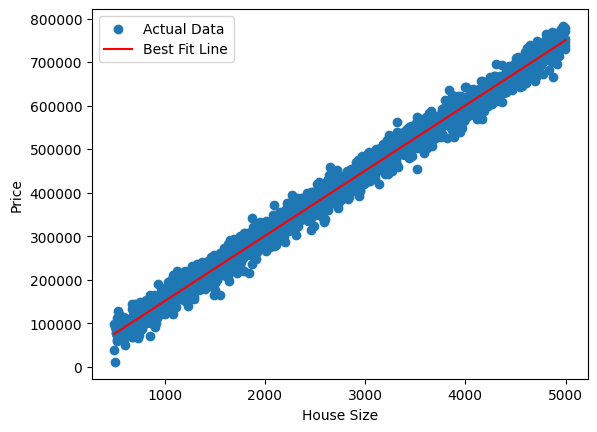

In [13]:

# Scatter plot (actual data)
plt.scatter(X_test, y_test, label="Actual Data")

# --- IMPORTANT PART ---
# Sort X values for a clean straight line
X_test_sorted = np.sort(X_test.values, axis=0)
y_pred_sorted = model.predict(X_test_sorted)

# Plot best fit line
plt.plot(X_test_sorted, y_pred_sorted, label="Best Fit Line",color='red')

plt.xlabel("House Size")
plt.ylabel("Price")
plt.legend()
plt.show()


In [14]:
print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

Slope (m): 149.87782426073682
Intercept (b): 662.0015976874274


In [15]:
data.head()

,House_Size_sqft,Price
0,2185.430535,298057.346152
1,4778.214379,694228.434792
2,3793.972738,576872.288928
3,3193.963179,455617.010307
4,1202.083882,202565.268403
